In [1]:
!pip install SimpleITK monai lungmask tqdm matplotlib -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 28.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os, glob, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import SimpleITK as sitk
from lungmask import mask as lungmask_model
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

BASE_DIR = '/content/drive/MyDrive/LUNA16_Project'

# ── Constants (must match Stage 1 / Stage 2 / Testing notebooks) ──────────────
HU_MIN       = -1000.0
HU_MAX       =  400.0
NEW_SPACING  = [1.0, 1.0, 1.0]   # isotropic 1 mm after resampling
PATCH_SIZE   = 64
LUNG_MASK_RATIO = 0.30            # patch must be ≥30% inside lung to be kept

# ── Discover scan files ───────────────────────────────────────────────────────
mhd_files = []
for i in range(10):
    mhd_files += glob.glob(os.path.join(BASE_DIR, f'subset{i}', '**', '*.mhd'), recursive=True)
mhd_files = sorted(set(mhd_files))

print(f'MHD scan files found : {len(mhd_files)}')


MHD scan files found : 888


---
## Section 2 — CT Preprocessing Helpers


In [4]:
def resample_scan(itk_img, new_spacing=NEW_SPACING):
    """
    Resample a CT scan to isotropic 1 mm spacing using linear interpolation.
    Required so every patch covers the same physical volume regardless of scanner.
    """
    orig_sp = np.array(itk_img.GetSpacing())
    orig_sz = np.array(itk_img.GetSize())
    new_sz  = [int(round(orig_sz[i] * (orig_sp[i] / new_spacing[i]))) for i in range(3)]

    r = sitk.ResampleImageFilter()
    r.SetOutputSpacing(new_spacing)
    r.SetSize(new_sz)
    r.SetOutputDirection(itk_img.GetDirection())
    r.SetOutputOrigin(itk_img.GetOrigin())
    r.SetTransform(sitk.Transform())
    r.SetInterpolator(sitk.sitkLinear)
    return r.Execute(itk_img)


def preprocess_scan(mhd_path):
    """
    Load .mhd, resample to 1 mm isotropic, clip HU to [-1000, 400], normalise to [0,1].
    Returns: (arr float32 Z×Y×X, origin mm, spacing mm, resampled_itk_img)
    """
    itk_img   = sitk.ReadImage(mhd_path)
    resampled = resample_scan(itk_img)
    arr       = sitk.GetArrayFromImage(resampled).astype(np.float32)
    origin    = np.array(resampled.GetOrigin())
    spacing   = np.array(resampled.GetSpacing())
    arr       = np.clip(arr, HU_MIN, HU_MAX)
    arr       = (arr - HU_MIN) / (HU_MAX - HU_MIN)
    return arr, origin, spacing, resampled


def generate_lung_mask(resampled_itk_img):
    """
    Run the lungmask U-Net on a resampled SimpleITK image.
    Returns: binary np.uint8 array (Z, Y, X) — 1 = lung, 0 = non-lung.
    Labels >0 cover both left and right lung segments.
    """
    raw_mask = lungmask_model.apply(resampled_itk_img)   # shape Z×Y×X, values 0/1/2
    return (raw_mask > 0).astype(np.uint8)


print('Helpers defined.')


Helpers defined.


---
## Section 3 — Generate a Lung Mask on a Single Scan


In [5]:
if len(mhd_files) == 0:
    raise RuntimeError('No MHD files found. Check BASE_DIR and subset folder structure.')

# Use the first available scan for demonstration
demo_path = mhd_files[0]
pid       = os.path.basename(demo_path).replace('.mhd', '')
print(f'Demo scan : {pid}')
print('Loading and resampling ...', end=' ')

arr, origin, spacing, resampled_img = preprocess_scan(demo_path)
print(f'done  →  array shape: {arr.shape}  (Z, Y, X)')

print('Generating lung mask ...', end=' ')
lung_mask = generate_lung_mask(resampled_img)
print('done')

lung_voxels  = lung_mask.sum()
total_voxels = lung_mask.size
print()
print(f'Lung voxels          : {lung_voxels:,}')
print(f'Total voxels         : {total_voxels:,}')
print(f'Lung fraction        : {lung_voxels / total_voxels * 100:.1f}%')
print(f'Mask unique values   : {np.unique(lung_mask)}  (0=background, 1=lung)')


Demo scan : 1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260
Loading and resampling ... done  →  array shape: (302, 390, 390)  (Z, Y, X)
Generating lung mask ... Downloading: "https://github.com/JoHof/lungmask/releases/download/v0.0/unet_r231-d5d2fc3d.pth" to /root/.cache/torch/hub/checkpoints/unet_r231-d5d2fc3d.pth


100%|██████████| 119M/119M [00:03<00:00, 37.1MB/s]
16it [00:07,  2.09it/s]                          

lungmask 2026-05-04 07:52:46 Postprocessing



100%|██████████| 2/2 [00:00<00:00, 89.97it/s]


done

Lung voxels          : 6,625,066
Total voxels         : 45,934,200
Lung fraction        : 14.4%
Mask unique values   : [0 1]  (0=background, 1=lung)


---
## Section 4 — Visualising the Mask


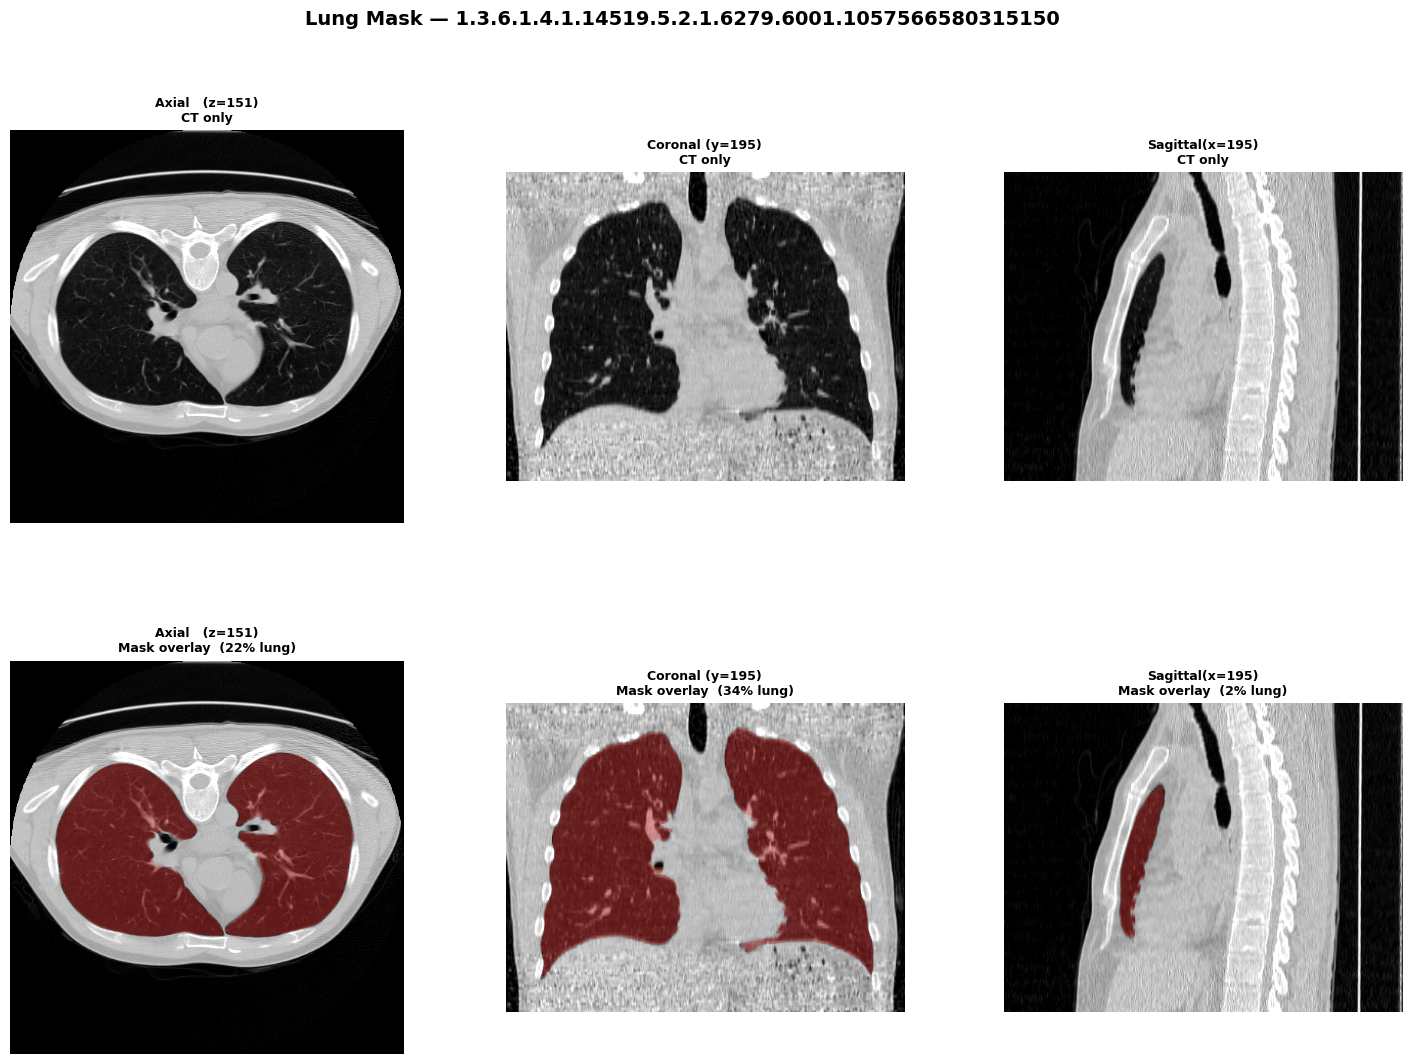

Saved → lung_mask_overlay.png


In [6]:
def show_mask_overlay(arr, mask, title='Lung Mask Overlay'):
    """
    Show axial, coronal, and sagittal slices with the mask overlaid in red.
    arr  : normalised CT array (Z, Y, X), values in [0, 1]
    mask : binary lung mask (Z, Y, X), values in {0, 1}
    """
    D, H, W = arr.shape

    # Choose centre slices
    z_mid = D // 2
    y_mid = H // 2
    x_mid = W // 2

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.25)

    views = [
        ('Axial   (z=%d)'  % z_mid, arr[z_mid],  mask[z_mid]),
        ('Coronal (y=%d)'  % y_mid, arr[:, y_mid, :],  mask[:, y_mid, :]),
        ('Sagittal(x=%d)'  % x_mid, arr[:, :, x_mid],  mask[:, :, x_mid]),
    ]

    for col, (label, ct_slice, m_slice) in enumerate(views):
        # Top row: CT only
        ax_top = fig.add_subplot(gs[0, col])
        ax_top.imshow(ct_slice, cmap='gray', vmin=0, vmax=1, origin='lower')
        ax_top.set_title(f'{label}\nCT only', fontweight='bold', fontsize=9)
        ax_top.axis('off')

        # Bottom row: CT + mask overlay
        ax_bot = fig.add_subplot(gs[1, col])
        ax_bot.imshow(ct_slice, cmap='gray', vmin=0, vmax=1, origin='lower')
        overlay = np.zeros((*ct_slice.shape, 4), dtype=np.float32)
        overlay[m_slice == 1] = [1.0, 0.2, 0.2, 0.35]  # red, semi-transparent
        ax_bot.imshow(overlay, origin='lower')
        lung_pct = m_slice.sum() / m_slice.size * 100
        ax_bot.set_title(f'{label}\nMask overlay  ({lung_pct:.0f}% lung)', fontweight='bold', fontsize=9)
        ax_bot.axis('off')

    plt.savefig('lung_mask_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → lung_mask_overlay.png')


show_mask_overlay(arr, lung_mask, title=f'Lung Mask — {pid[:50]}')


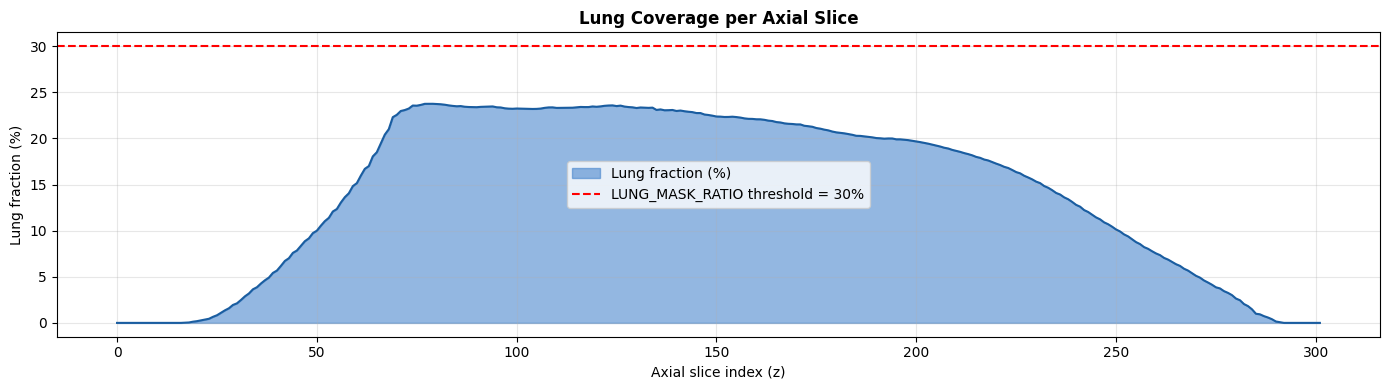

Saved → lung_depth_profile.png


In [7]:
# ── Depth profile: lung fraction per axial slice ──────────────────────────────
lung_per_slice = lung_mask.sum(axis=(1, 2)) / (lung_mask.shape[1] * lung_mask.shape[2])

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(len(lung_per_slice)), lung_per_slice * 100,
                alpha=0.55, color='#3A7DC9', label='Lung fraction (%)')
ax.plot(lung_per_slice * 100, color='#1A5DA0', linewidth=1.5)
ax.axhline(LUNG_MASK_RATIO * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'LUNG_MASK_RATIO threshold = {LUNG_MASK_RATIO*100:.0f}%')
ax.set_xlabel('Axial slice index (z)')
ax.set_ylabel('Lung fraction (%)')
ax.set_title('Lung Coverage per Axial Slice', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lung_depth_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → lung_depth_profile.png')


---
## Section 5 — Batch Mask Generation Quality Check

In [8]:
import gc

NUM_SAMPLE = min(10, len(mhd_files))   # adjust upward for a fuller check
sample_files = random.sample(mhd_files, NUM_SAMPLE)

results = []

for mhd_path in tqdm(sample_files, desc='Mask quality check'):
    pid_name = os.path.basename(mhd_path).replace('.mhd', '')
    try:
        _, _, _, rimg = preprocess_scan(mhd_path)
        m = generate_lung_mask(rimg)
        lung_frac = m.sum() / m.size
        flag = '  LOW' if lung_frac < 0.03 else ('  HIGH' if lung_frac > 0.60 else '✅')
        results.append({'pid': pid_name[:45], 'lung_frac_%': round(lung_frac*100, 2), 'status': flag})
        del m, rimg
        gc.collect()
    except Exception as e:
        results.append({'pid': pid_name[:45], 'lung_frac_%': -1, 'status': f'ERROR: {e}'})

import pandas as pd
df_quality = pd.DataFrame(results)
display(df_quality)

print()
print(f'Scans checked  : {len(df_quality)}')
print(f'Pass (✅)       : {(df_quality["status"]=="✅").sum()}')
print(f'Warnings (⚠️)  : {df_quality["status"].str.startswith("⚠️").sum()}')
print(f'Errors         : {df_quality["status"].str.startswith("ERROR").sum()}')


Mask quality check:   0%|          | 0/10 [00:00<?, ?it/s]


  0%|          | 0/14.75 [00:00<?, ?it/s]
  7%|▋         | 1/14.75 [00:00<00:06,  2.06it/s]
 14%|█▎        | 2/14.75 [00:00<00:05,  2.33it/s]
 20%|██        | 3/14.75 [00:01<00:04,  2.43it/s]
 27%|██▋       | 4/14.75 [00:01<00:04,  2.47it/s]
 34%|███▍      | 5/14.75 [00:02<00:03,  2.50it/s]
 41%|████      | 6/14.75 [00:02<00:03,  2.51it/s]
 47%|████▋     | 7/14.75 [00:02<00:03,  2.52it/s]
 54%|█████▍    | 8/14.75 [00:03<00:02,  2.52it/s]
 61%|██████    | 9/14.75 [00:03<00:02,  2.52it/s]
 68%|██████▊   | 10/14.75 [00:04<00:01,  2.52it/s]
 75%|███████▍  | 11/14.75 [00:04<00:01,  2.52it/s]
 81%|████████▏ | 12/14.75 [00:04<00:01,  2.52it/s]
 88%|████████▊ | 13/14.75 [00:05<00:00,  2.51it/s]
 95%|█████████▍| 14/14.75 [00:05<00:00,  2.51it/s]
102%|██████████| 15/14.75 [00:05<-00:00,  2.55it/s]

lungmask 2026-05-04 07:54:14 Postprocessing




100%|██████████| 5/5 [00:00<00:00, 33.86it/s]

  0%|          | 0/16.75 [00:00<?, ?it/s]
  6%|▌         | 1/16.75 [00:00<00:07,  2.25it/s]
 12%|█▏        | 2/16.75 [00:00<00:06,  2.39it/s]
 18%|█▊        | 3/16.75 [00:01<00:05,  2.46it/s]
 24%|██▍       | 4/16.75 [00:01<00:05,  2.48it/s]
 30%|██▉       | 5/16.75 [00:02<00:04,  2.50it/s]
 36%|███▌      | 6/16.75 [00:02<00:04,  2.50it/s]
 42%|████▏     | 7/16.75 [00:02<00:03,  2.50it/s]
 48%|████▊     | 8/16.75 [00:03<00:03,  2.51it/s]
 54%|█████▎    | 9/16.75 [00:03<00:03,  2.51it/s]
 60%|█████▉    | 10/16.75 [00:04<00:02,  2.49it/s]
 66%|██████▌   | 11/16.75 [00:04<00:02,  2.48it/s]
 72%|███████▏  | 12/16.75 [00:04<00:01,  2.48it/s]
 78%|███████▊  | 13/16.75 [00:05<00:01,  2.48it/s]
 84%|████████▎ | 14/16.75 [00:05<00:01,  2.47it/s]
 90%|████████▉ | 15/16.75 [00:06<00:00,  2.47it/s]
 96%|█████████▌| 16/16.75 [00:06<00:00,  2.47it/s]
101%|██████████| 17/16.75 [00:06<-00:00,  2.53it/s]

lungmask 2026-05-04 07:54:33 Postprocessing


...



100%|██████████| 6/6 [00:00<00:00, 84.64it/s]

  0%|          | 0/16.5 [00:00<?, ?it/s]
  6%|▌         | 1/16.5 [00:00<00:07,  2.12it/s]
 12%|█▏        | 2/16.5 [00:00<00:06,  2.21it/s]
 18%|█▊        | 3/16.5 [00:01<00:06,  2.23it/s]
 24%|██▍       | 4/16.5 [00:01<00:05,  2.24it/s]
 30%|███       | 5/16.5 [00:02<00:05,  2.24it/s]
 36%|███▋      | 6/16.5 [00:02<00:04,  2.24it/s]
 42%|████▏     | 7/16.5 [00:03<00:04,  2.24it/s]
 48%|████▊     | 8/16.5 [00:03<00:03,  2.24it/s]
 55%|█████▍    | 9/16.5 [00:04<00:03,  2.23it/s]
 61%|██████    | 10/16.5 [00:04<00:02,  2.22it/s]
 67%|██████▋   | 11/16.5 [00:04<00:02,  2.21it/s]
 73%|███████▎  | 12/16.5 [00:05<00:02,  2.22it/s]
 79%|███████▉  | 13/16.5 [00:05<00:01,  2.21it/s]
 85%|████████▍ | 14/16.5 [00:06<00:01,  2.20it/s]
 91%|█████████ | 15/16.5 [00:06<00:00,  2.20it/s]
 97%|█████████▋| 16/16.5 [00:07<00:00,  2.19it/s]
17it [00:07,  2.28it/s]

lungmask 2026-05-04 07:57:56 Postprocessing




100%|██████████| 5/5 [00:00<00:00, 84.29it/s]


,pid,lung_frac_%,status
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.22365012281,8.11,✅
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.16912813626,11.48,✅
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.20281168411,5.21,✅
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.28662748519,13.43,✅
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.16284530924,16.61,✅
5,1.3.6.1.4.1.14519.5.2.1.6279.6001.46115550551,11.28,✅
6,1.3.6.1.4.1.14519.5.2.1.6279.6001.25263463882,7.93,✅
7,1.3.6.1.4.1.14519.5.2.1.6279.6001.28251204325,8.79,✅
8,1.3.6.1.4.1.14519.5.2.1.6279.6001.26287306916,15.79,✅
9,1.3.6.1.4.1.14519.5.2.1.6279.6001.14660391050,14.76,✅



Scans checked  : 10
Pass (✅)       : 10
Warnings (⚠️)  : 0
Errors         : 0


---
## Section 6 — Effect on Sliding-Window Coverage

  Sliding-Window Coverage Analysis
  Scan shape (Z,Y,X)      : 302 × 390 × 390
  Stride                  : 16 voxels
  Total windows (no mask) : 6,615
  Windows inside lung     : 2,064
  Windows eliminated      : 4,551  (68.8% reduction)


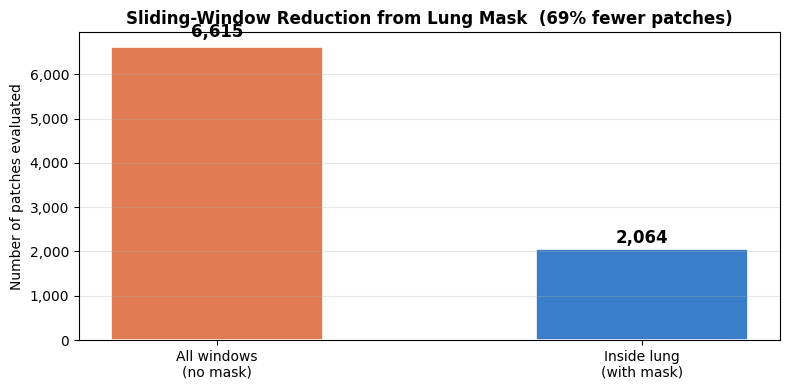

Saved → lung_mask_window_reduction.png


In [9]:
# Re-use the demo scan loaded in Section 3
STRIDE = 16   # matches Stage 1 & Testing notebooks

D, H, W = arr.shape

total_windows = 0
masked_windows = 0

for z in range(0, D - PATCH_SIZE + 1, STRIDE):
    for y in range(0, H - PATCH_SIZE + 1, STRIDE):
        for x in range(0, W - PATCH_SIZE + 1, STRIDE):
            total_windows += 1
            block = lung_mask[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            if block.sum() >= LUNG_MASK_RATIO * PATCH_SIZE**3:
                masked_windows += 1

eliminated = total_windows - masked_windows
reduction  = eliminated / total_windows * 100

print('=' * 55)
print('  Sliding-Window Coverage Analysis')
print('=' * 55)
print(f'  Scan shape (Z,Y,X)      : {D} × {H} × {W}')
print(f'  Stride                  : {STRIDE} voxels')
print(f'  Total windows (no mask) : {total_windows:,}')
print(f'  Windows inside lung     : {masked_windows:,}')
print(f'  Windows eliminated      : {eliminated:,}  ({reduction:.1f}% reduction)')
print('=' * 55)

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['All windows\n(no mask)', 'Inside lung\n(with mask)'],
              [total_windows, masked_windows],
              color=['#E07B54', '#3A7DC9'],
              edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, [total_windows, masked_windows]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title(f'Sliding-Window Reduction from Lung Mask  ({reduction:.0f}% fewer patches)',
             fontweight='bold')
ax.set_ylabel('Number of patches evaluated')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lung_mask_window_reduction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → lung_mask_window_reduction.png')
